# 02 · EDA — 옥수수 수확량과 온도 노출

입력: `data/processed/corn_panel.parquet` (70,721행 / 2,644 카운티 / 1981–2015)

그림은 모두 화면에 표시하고 `outputs/figures/`에 PNG로 저장한다.
`data/raw/`는 읽지 않는다 (전처리 산출물만 사용).

### 이 노트북이 확인하려는 것
1. 수확량의 장기 추세와 분포
2. `gdd` 121개 컬럼이 만드는 **온도 노출 분포**의 형태
3. **29℃ 임계점 신호** — 고온 노출이 늘수록 수확량이 꺾이는가
4. 인접 온도구간 간 **다중공선성** (Ridge/Lasso 도입 근거)
5. `slope` 결측 2,061개의 패턴

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap

PROC = Path('..') / 'data' / 'processed'
FIG = Path('..') / 'outputs' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

# --- validated palette (dataviz reference instance, light mode) ---
SURFACE, INK, SECOND, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED = '#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948'
CAT5 = [BLUE, AQUA, YELLOW, GREEN, VIOLET]
DIVERGING = LinearSegmentedColormap.from_list('bl_gy_rd', [BLUE, '#f0efec', RED])

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SECOND, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Malgun Gothic', 'Segoe UI', 'DejaVu Sans'],  # Malgun Gothic = 한글 글리프
    'axes.unicode_minus': False,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold',
    'axes.labelsize': 11, 'lines.linewidth': 2,
})

def save(fig, name):
    p = FIG / name
    fig.savefig(p, bbox_inches='tight')
    print('saved:', p)

df = pd.read_parquet(PROC / 'corn_panel.parquet')
print('panel:', df.shape)

# --- gdd column geometry ---
GDD = [c for c in df.columns if c.startswith('gdd')]
def temp_of(c):
    if c == 'gdd0':
        return 0
    return int(c[4:]) if c.startswith('gddp') else -int(c[4:])
TEMPS = np.array([temp_of(c) for c in GDD])
G = df[GDD].to_numpy()

row_sum = np.nansum(G, axis=1)
print('gdd row-sum: mean %.2f  std %.4f  (= days in Mar-Aug)' % (row_sum.mean(), row_sum.std()))
SOIL = ['whc','sand','silt','clay','om','kwfactor','kffactor','spH','slope','tfactor']

Matplotlib is building the font cache; this may take a moment.


panel: (70721, 136)
gdd row-sum: mean 184.00  std 0.0149  (= days in Mar-Aug)


> **주의 — 이 데이터의 실제 의미**
>
> 각 행의 gdd 121개 컬럼 합이 **항상 ≈184로 일정**하다 (std 0.0001). 184는 3~8월의 일수다.
> 즉 이 컬럼들은 degree-days 총량이 아니라 **각 1℃ 구간에서 보낸 일수(exposure days) 분포**다
> (Schlenker–Roberts 스타일). 총합이 고정이므로 "총 노출량"은 카운티를 구분하지 못하고,
> **분포의 모양(어느 온도에 시간을 보냈는가)** 만이 정보를 담는다. 아래 분석은 이 점을 전제로 한다.

## 1. 수확량 추세와 분포

/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.s

saved: ../outputs/figures/fig01_yield_trend.png


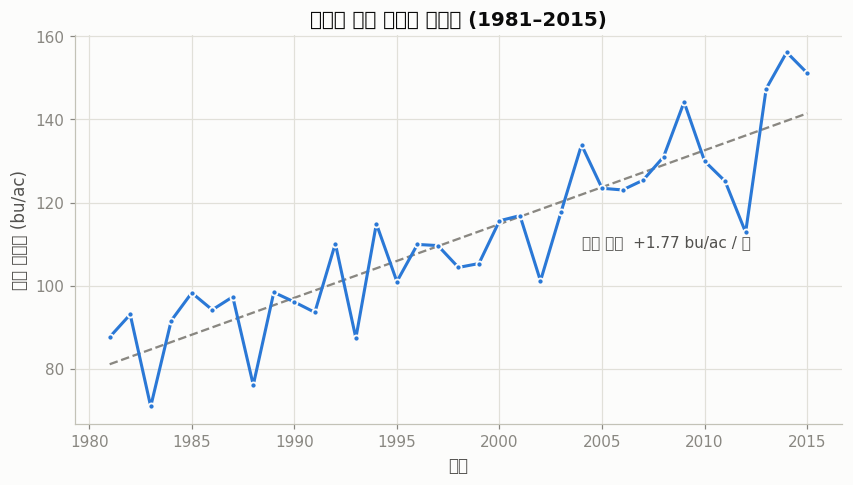

1981 평균 87.7  ->  2015 평균 151.1  (총 +63.5 bu/ac)


In [2]:
yearly = df.groupby('year')['corn'].mean()
slope_fit, intercept = np.polyfit(yearly.index, yearly.values, 1)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.set_axisbelow(True)
ax.plot(yearly.index, yearly.values, color=BLUE, marker='o', markersize=4,
        markerfacecolor=BLUE, markeredgecolor=SURFACE, markeredgewidth=1.2, zorder=3)
ax.plot(yearly.index, intercept + slope_fit * yearly.index, color=MUTED,
        linestyle='--', linewidth=1.5, zorder=2)
ax.annotate('선형 추세  +%.2f bu/ac / 년' % slope_fit,
            xy=(2004, intercept + slope_fit * 2004), xytext=(0, -34),
            textcoords='offset points', color=SECOND, fontsize=10)
ax.set_title('연도별 평균 옥수수 수확량 (1981–2015)')
ax.set_xlabel('연도'); ax.set_ylabel('평균 수확량 (bu/ac)')
save(fig, 'fig01_yield_trend.png'); plt.show()

print('1981 평균 %.1f  ->  2015 평균 %.1f  (총 +%.1f bu/ac)'
      % (yearly.iloc[0], yearly.iloc[-1], yearly.iloc[-1] - yearly.iloc[0]))

saved: ../outputs/figures/fig02_corn_hist.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 50725 (\N{HANGUL SYLLABLE OG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.save

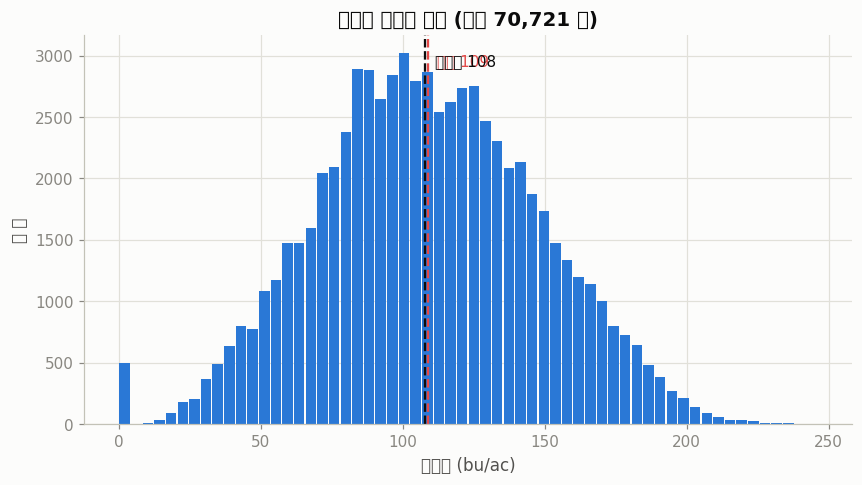

count    70721.0
mean       108.9
std         38.8
min          0.0
25%         82.0
50%        108.0
75%        136.0
max        246.0
0 bu/ac 인 행: 501


In [3]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.set_axisbelow(True)
ax.hist(df['corn'], bins=60, color=BLUE, rwidth=0.9)
for val, lab, col in [(df['corn'].mean(), '평균', RED), (df['corn'].median(), '중앙값', INK)]:
    ax.axvline(val, color=col, linestyle='--', linewidth=1.5)
    ax.annotate('%s %.0f' % (lab, val), xy=(val, ax.get_ylim()[1] * 0.92),
                xytext=(6, 0), textcoords='offset points', color=col, fontsize=10)
ax.set_title('옥수수 수확량 분포 (전체 70,721 행)')
ax.set_xlabel('수확량 (bu/ac)'); ax.set_ylabel('행 수')
save(fig, 'fig02_corn_hist.png'); plt.show()

print(df['corn'].describe().round(1).to_string())
print('0 bu/ac 인 행:', int((df['corn'] == 0).sum()))

**해석 —** 평균 수확량은 1981년 **87.7 bu/ac**에서 2015년 **151.1 bu/ac**로 뚜렷하게 상승한다
(선형 추세 **+1.77 bu/ac/년**, 총 +63.5). 품종·농법 개선에 따른 기술 추세로, 기후 효과를 보려면
**연도 효과를 반드시 제거**해야 한다는 뜻이다 (3절에서 연도 평균을 뺀 버전을 함께 본다).

분포는 평균 108.9 / 중앙값 108.0의 대체로 대칭적인 단봉형이며, 1988·2012년 같은 가뭄 해가
왼쪽 꼬리를 만든다. 수확량이 정확히 0인 행도 **501개** 있다 (완전 흉작).

## 2. 온도 노출 분포의 형태

각 행은 온도축(−60…+60℃) 위의 분포다. 평균 노출이 실질적으로 존재하는 구간은 **−23℃ ~ +43℃** 범위다.

평균 노출이 있는 온도 구간: -23℃ ~ 43℃
saved: ../outputs/figures/fig03_gdd_shape.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.savefig(p

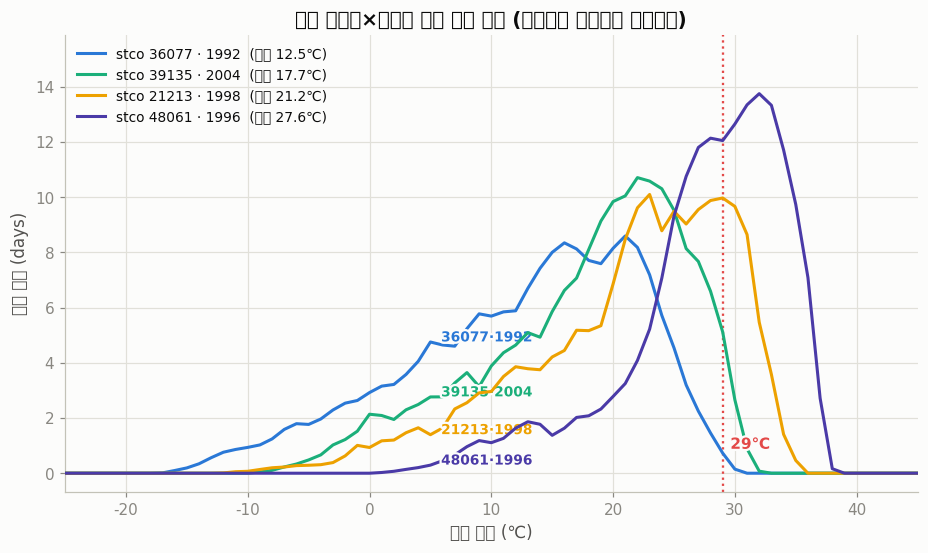

 stco  year  wmean_temp  corn  >29℃ 노출일수
36077  1992       12.52  86.0        0.1
39135  2004       17.72 172.4        3.6
21213  1998       21.16 128.0       29.2
48061  1996       27.62  94.1       84.5


In [4]:
mean_exposure = np.nanmean(G, axis=0)
mask = mean_exposure > 0.005
lo, hi = TEMPS[mask].min(), TEMPS[mask].max()
print('평균 노출이 있는 온도 구간: %d℃ ~ %d℃' % (lo, hi))

wmean = np.nansum(G * TEMPS, axis=1) / row_sum   # 노출가중 평균기온
df['wmean_temp'] = wmean

qs = [0.01, 0.35, 0.70, 0.995]     # 4개: 직접 라벨이 서로 겹치지 않는 한도
CAT4 = [BLUE, AQUA, YELLOW, VIOLET]
idx = [int(np.nanargmin(np.abs(wmean - np.nanquantile(wmean, q)))) for q in qs]

fig, ax = plt.subplots(figsize=(10, 5.4))
ax.set_axisbelow(True)
halo = [pe.withStroke(linewidth=3, foreground=SURFACE)]

# 봉우리는 서로 뭉쳐 있고 상승 flank에서는 곡선이 평균기온 순으로 벌어진다.
# -> 라벨을 상승 flank(ANCHOR_X)에 붙이면 충돌 없이 세로로 분리된다.
ANCHOR_X = 5
ax_i = int(np.where(TEMPS == ANCHOR_X)[0][0])

for k, i in enumerate(idx):
    r = df.iloc[i]
    y = G[i]
    ax.plot(TEMPS, y, color=CAT4[k], zorder=3,
            label='stco %d · %d  (평균 %.1f℃)' % (r.stco, r.year, r.wmean_temp))
    # 직접 라벨 (relief rule: aqua/yellow은 이 surface에서 3:1 미만)
    ax.annotate('%d·%d' % (r.stco, r.year), xy=(ANCHOR_X, y[ax_i]),
                xytext=(7, 3), textcoords='offset points', va='center', ha='left',
                color=CAT4[k], fontsize=9, fontweight='semibold', path_effects=halo)

ax.set_xlim(lo - 2, hi + 2)
ax.set_ylim(top=ax.get_ylim()[1] * 1.10)
ax.axvline(29, color=RED, linestyle=':', linewidth=1.5, zorder=2)
ax.annotate('29℃', xy=(29, 0), xytext=(5, 16), textcoords='offset points',
            color=RED, fontsize=10, fontweight='semibold', path_effects=halo)
ax.set_title('샘플 카운티×연도의 온도 노출 분포 (노출가중 평균기온 분위수별)')
ax.set_xlabel('온도 구간 (℃)'); ax.set_ylabel('노출 일수 (days)')
ax.legend(frameon=False, fontsize=9, loc='upper left')
save(fig, 'fig03_gdd_shape.png'); plt.show()

# table view (색만으로 식별하지 않도록 하는 보조 채널)
tbl = df.iloc[idx][['stco', 'year', 'wmean_temp', 'corn']].copy()
tbl['>29℃ 노출일수'] = df.iloc[idx][[c for c in GDD if c.startswith('gddp') and 30 <= temp_of(c) <= 60]].sum(axis=1).round(1)
print(tbl.round(2).to_string(index=False))

In [5]:
# --- 평균기온은 거의 같은데 고온 노출이 크게 다른 두 사례 찾기 ---
above = [c for c in GDD if c.startswith('gddp') and 30 <= temp_of(c) <= 60]
below = [c for c in GDD if c.startswith('gddp') and 1 <= temp_of(c) <= 29]
df['GDD_above29'] = df[above].sum(axis=1)
df['GDD_below29'] = df[below].sum(axis=1)

o = df.dropna(subset=['wmean_temp']).sort_values('wmean_temp').reset_index(drop=True)
wm, a29 = o['wmean_temp'].to_numpy(), o['GDD_above29'].to_numpy()
best = None
for w in (30, 80, 200):
    for i in range(len(o) - w):
        j = i + w
        if abs(wm[j] - wm[i]) < 0.05:
            gap = abs(a29[j] - a29[i])
            if best is None or gap > best[0]:
                best = (gap, i, j)
gap, i, j = best
r_hot, r_mild = (o.loc[i], o.loc[j]) if a29[i] > a29[j] else (o.loc[j], o.loc[i])
print('평균기온 차이: %.3f℃   |   >29℃ 노출 차이: %.1f 일' % (abs(r_hot.wmean_temp - r_mild.wmean_temp), gap))
for tag, r in [('HOT ', r_hot), ('MILD', r_mild)]:
    print('  %s stco=%d year=%d  wmean=%.2f℃  >29℃=%.1f일  <29℃=%.1f일  corn=%.1f bu/ac'
          % (tag, r.stco, r.year, r.wmean_temp, r.GDD_above29, r.GDD_below29, r.corn))

평균기온 차이: 0.012℃   |   >29℃ 노출 차이: 37.6 일
  HOT  stco=20063 year=2011  wmean=20.51℃  >29℃=44.8일  <29℃=130.0일  corn=95.4 bu/ac
  MILD stco=47031 year=2004  wmean=20.52℃  >29℃=7.3일  <29℃=175.7일  corn=153.0 bu/ac


saved: ../outputs/figures/fig04_matched_pair.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.savefig

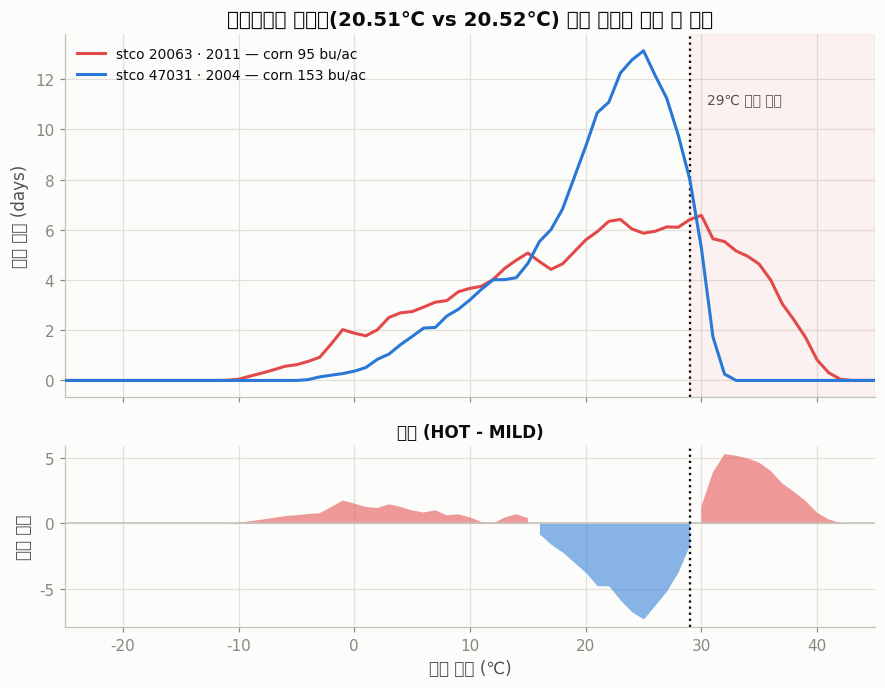

In [6]:
# exposure vectors for the two chosen rows
def vec(row):
    return row[GDD].to_numpy(dtype=float)
v_hot, v_mild = vec(r_hot), vec(r_mild)

fig, axes = plt.subplots(2, 1, figsize=(9.5, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.18})
ax = axes[0]; ax.set_axisbelow(True)
lab_hot = 'stco %d · %d — corn %.0f bu/ac' % (r_hot.stco, r_hot.year, r_hot.corn)
lab_mild = 'stco %d · %d — corn %.0f bu/ac' % (r_mild.stco, r_mild.year, r_mild.corn)
ax.plot(TEMPS, v_hot, color=RED, zorder=3, label=lab_hot)
ax.plot(TEMPS, v_mild, color=BLUE, zorder=3, label=lab_mild)
ax.axvline(29, color=INK, linestyle=':', linewidth=1.5, zorder=2)
ax.axvspan(29, hi + 2, color=RED, alpha=0.06, zorder=1)
ax.annotate('29℃ 초과 구간', xy=(30.5, ax.get_ylim()[1] * 0.8), color=SECOND, fontsize=9)
ax.set_title('평균기온은 같지만(%.2f℃ vs %.2f℃) 고온 노출이 다른 두 사례'
             % (r_hot.wmean_temp, r_mild.wmean_temp))
ax.set_ylabel('노출 일수 (days)')
ax.legend(frameon=False, fontsize=9, loc='upper left')

ax2 = axes[1]; ax2.set_axisbelow(True)
d = v_hot - v_mild
ax2.fill_between(TEMPS, 0, d, where=d >= 0, color=RED, alpha=0.55, linewidth=0)
ax2.fill_between(TEMPS, 0, d, where=d < 0, color=BLUE, alpha=0.55, linewidth=0)
ax2.axhline(0, color=AXIS, linewidth=1)
ax2.axvline(29, color=INK, linestyle=':', linewidth=1.5)
ax2.set_xlim(lo - 2, hi + 2)
ax2.set_title('차이 (HOT - MILD)', fontsize=11)   # ASCII 하이픈: Malgun Gothic에 U+2212 글리프 없음
ax2.set_xlabel('온도 구간 (℃)'); ax2.set_ylabel('일수 차이')
save(fig, 'fig04_matched_pair.png'); plt.show()

**해석 —** 노출 분포는 대체로 15~25℃에 봉우리를 갖는 단봉형이고, 더운 카운티일수록 봉우리가
오른쪽으로 이동하면서 **오른쪽 꼬리(>29℃)가 두꺼워진다**.

매칭된 두 사례가 이 프로젝트의 핵심을 요약한다: **노출가중 평균기온은 20.5℃로 사실상 동일**한데
(<0.05℃ 차이), >29℃ 노출은 **7일 vs 45일**로 6배 넘게 차이 나고 수확량은 **153 → 95 bu/ac**로
약 58 bu/ac 낮다. 아래 차이 패널을 보면 HOT 사례는 29℃ 위쪽에 시간을 더 쓰고 그만큼 20℃ 근처의
유익한 시간을 잃었다. **평균기온 하나로는 이 차이를 설명할 수 없다** — 분포 전체가 필요하다.

## 3. 수확량 vs 고온 노출 — 29℃ 임계점 신호

- `GDD_above29` = `gddp30` … `gddp60` 합 (유해 고온 노출, 일수)
- `GDD_below29` = `gddp1` … `gddp29` 합 (유익 노출, 일수)

산점도 70,721점은 겹치므로 낮은 alpha로 깔고, 그 위에 **구간별 평균(비모수)** 과
**3차 다항 fit**을 얹어 비선형성을 드러낸다. (`statsmodels`가 없어 lowess 대신 다항 fit + binned mean 사용)

/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  fig.savefi

saved: ../outputs/figures/fig05_yield_vs_exposure.png


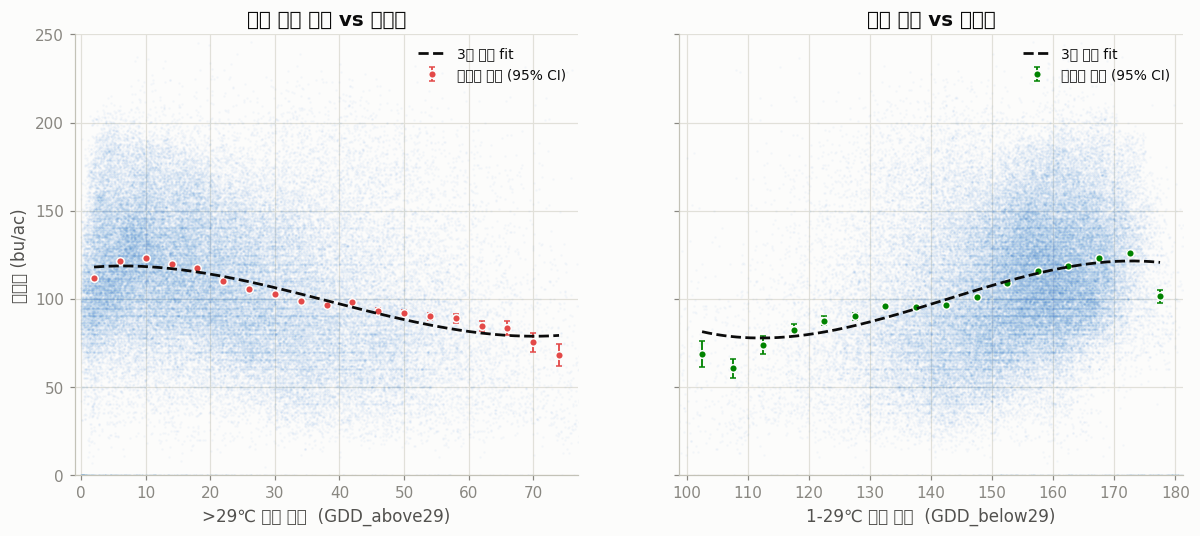

above29 구간별 평균: 정점 123.1 bu/ac (x=10일)  ->  최저 68.0 bu/ac (x=74일)
  (노출 0-4일 구간도 112.1 로 낮음 -> 역U자: 냉량지역은 고온부족으로 낮음)
below29 구간별 평균: 정점 126.1 bu/ac (x=172일), 최저 60.6 bu/ac (x=108일)
  (마지막 구간 101.4 은 표본 666행뿐인 극단 냉량지역 꼬리)

below29 vs above29 상관: -0.901  (총 184일 고정에서 오는 구성적 제약)


In [7]:
def binned_mean(x, y, edges, min_count=100):
    b = pd.cut(x, edges)
    g = pd.DataFrame({'y': y, 'b': b}).groupby('b', observed=True)['y'].agg(['mean', 'count', 'std'])
    g = g[g['count'] >= min_count]          # 소표본 구간 제외 (bin 순서 유지)
    centers = np.array([iv.mid for iv in g.index])
    cnt = g['count'].to_numpy()
    se = g['std'].to_numpy() / np.sqrt(cnt)
    return centers, g['mean'].to_numpy(), se, cnt

def panel(ax, x, y, edges, xlabel, title, fitcolor):
    ax.set_axisbelow(True)
    ax.scatter(x, y, s=2, color=BLUE, alpha=0.05, linewidths=0, zorder=1, rasterized=True)
    cx, cy, se, cnt = binned_mean(x, y, edges)
    ax.errorbar(cx, cy, yerr=1.96 * se, fmt='o', markersize=5, color=fitcolor,
                markeredgecolor=SURFACE, markeredgewidth=1.0, ecolor=fitcolor,
                elinewidth=1.2, capsize=2, zorder=4, label='구간별 평균 (95% CI)')
    # fit은 구간평균이 존재하는 범위까지만 그린다 (바깥은 외삽이라 오해 소지)
    xs = np.linspace(cx.min(), cx.max(), 200)
    coef = np.polyfit(x, y, 3)
    ax.plot(xs, np.polyval(coef, xs), color=INK, linestyle='--', linewidth=1.8,
            zorder=5, label='3차 다항 fit')
    half = (edges[1] - edges[0]) / 2
    ax.set_xlim(cx.min() - half * 1.5, cx.max() + half * 1.5)   # 마지막 점이 잘리지 않도록
    ax.set_xlabel(xlabel); ax.set_title(title)
    ax.legend(frameon=False, fontsize=9, loc='upper right')
    return cx, cy, cnt

x_a, x_b, y = df['GDD_above29'].to_numpy(), df['GDD_below29'].to_numpy(), df['corn'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
cxa, cya, cna = panel(axes[0], x_a, y, np.arange(0, 80, 4),
                      '>29℃ 노출 일수  (GDD_above29)', '유해 고온 노출 vs 수확량', RED)
cxb, cyb, cnb = panel(axes[1], x_b, y, np.arange(100, 190, 5),
                      '1-29℃ 노출 일수  (GDD_below29)', '유익 노출 vs 수확량', GREEN)
axes[0].set_ylabel('수확량 (bu/ac)')
axes[0].set_ylim(0, 250)
save(fig, 'fig05_yield_vs_exposure.png'); plt.show()

print('above29 구간별 평균: 정점 %.1f bu/ac (x=%.0f일)  ->  최저 %.1f bu/ac (x=%.0f일)'
      % (cya.max(), cxa[cya.argmax()], cya.min(), cxa[cya.argmin()]))
print('  (노출 0-4일 구간도 %.1f 로 낮음 -> 역U자: 냉량지역은 고온부족으로 낮음)' % cya[0])
print('below29 구간별 평균: 정점 %.1f bu/ac (x=%.0f일), 최저 %.1f bu/ac (x=%.0f일)'
      % (cyb.max(), cxb[cyb.argmax()], cyb.min(), cxb[cyb.argmin()]))
print('  (마지막 구간 %.1f 은 표본 %d행뿐인 극단 냉량지역 꼬리)' % (cyb[-1], cnb[-1]))
print('\nbelow29 vs above29 상관: %.3f  (총 184일 고정에서 오는 구성적 제약)'
      % df['GDD_below29'].corr(df['GDD_above29']))

/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 54200 (\N{HANGUL SYLLABLE PYEON}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.save

saved: ../outputs/figures/fig06_detrended_heat.png


/Users/leedonggeon/Desktop/Purdue_7/Purdue_code/purdue_git/climate-crop-optimization/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leedonggeon/Desktop/Purdue_7/Purdue_code/purdue_git/climate-crop-optimization/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leedonggeon/Desktop/Purdue_7/Purdue_code/purdue_git/climate-crop-optimization/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leedonggeon/Desktop/Purdue_7/Purdue_code/purdue_git/climate-crop-optimization/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: 

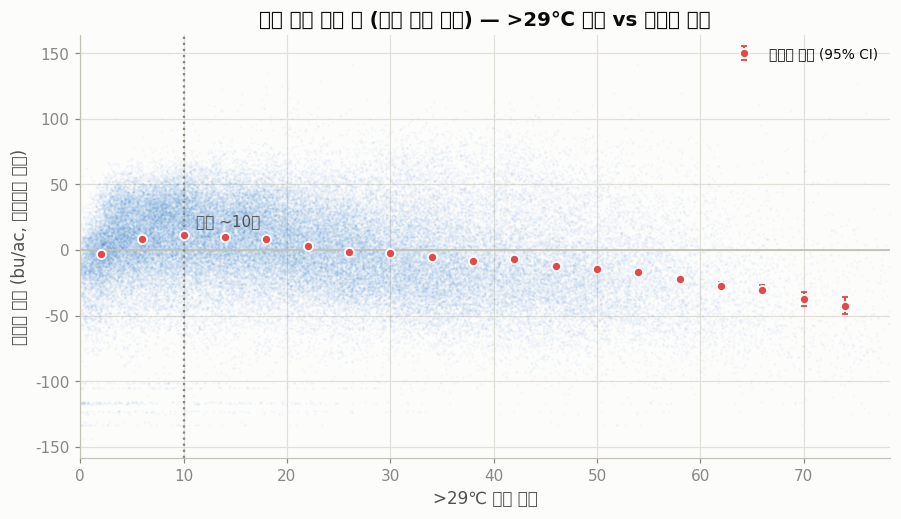


OLS (연도 demeaned corn ~ below29 + above29 + ppt):
  intercept      -66.610
  GDD_below29     +0.537
  GDD_above29     -0.128
  ppt             -0.020

  두 계수는 "≤0℃ 냉량일 1일을 해당 구간으로 바꿀 때"의 효과다.
  below29 1일 -> above29 1일 로 대체 시: -0.665 bu/ac  (= -0.128 - 0.537)


In [8]:
# 기술 추세(연도 효과)를 제거한 뒤에도 꺾임이 남는지 확인
df['corn_dm'] = df['corn'] - df.groupby('year')['corn'].transform('mean')

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.set_axisbelow(True)
ax.scatter(x_a, df['corn_dm'], s=2, color=BLUE, alpha=0.05, linewidths=0, zorder=1, rasterized=True)
cx, cy, se, _ = binned_mean(x_a, df['corn_dm'].to_numpy(), np.arange(0, 80, 4))
ax.errorbar(cx, cy, yerr=1.96 * se, fmt='o', markersize=6, color=RED,
            markeredgecolor=SURFACE, markeredgewidth=1.2, ecolor=RED,
            elinewidth=1.3, capsize=2, zorder=4, label='구간별 평균 (95% CI)')
ax.axhline(0, color=AXIS, linewidth=1.2, zorder=2)
peak = cx[cy.argmax()]
ax.axvline(peak, color=MUTED, linestyle=':', linewidth=1.5, zorder=2)
ax.annotate('정점 ~%.0f일' % peak, xy=(peak, cy.max()), xytext=(8, 6),
            textcoords='offset points', color=SECOND, fontsize=10)
ax.set_xlim(0, np.nanquantile(x_a, 0.995))
ax.set_title('연도 평균 제거 후 (기술 추세 통제) — >29℃ 노출 vs 수확량 편차')
ax.set_xlabel('>29℃ 노출 일수'); ax.set_ylabel('수확량 편차 (bu/ac, 연도평균 대비)')
ax.legend(frameon=False, fontsize=9, loc='upper right')
save(fig, 'fig06_detrended_heat.png'); plt.show()

# 두 노출을 동시에 통제한 단순 OLS (부호 확인용)
sub = df[['corn_dm', 'GDD_below29', 'GDD_above29', 'ppt']].dropna()
X = np.column_stack([np.ones(len(sub)), sub['GDD_below29'], sub['GDD_above29'], sub['ppt']])
beta, *_ = np.linalg.lstsq(X, sub['corn_dm'].to_numpy(), rcond=None)
names = ['intercept', 'GDD_below29', 'GDD_above29', 'ppt']
print('\nOLS (연도 demeaned corn ~ below29 + above29 + ppt):')
for n, b in zip(names, beta):
    print('  %-13s %+8.3f' % (n, b))
print('\n  두 계수는 "≤0℃ 냉량일 1일을 해당 구간으로 바꿀 때"의 효과다.')
print('  below29 1일 -> above29 1일 로 대체 시: %+.3f bu/ac  (= %.3f - %.3f)'
      % (beta[2] - beta[1], beta[2], beta[1]))

**해석 — 29℃ 임계 신호는 실제로 보인다. 다만 모양은 단순 감소가 아니라 역U자다.**

- 왼쪽 패널: 구간별 평균 수확량은 >29℃ 노출이 **약 8–12일일 때 정점(123.1 bu/ac)** 을 찍고,
  그 뒤로 **단조 감소**해 74일 부근에서 **68.0 bu/ac**까지 떨어진다 (−55 bu/ac).
  주목할 점은 노출이 **거의 없는 구간(0–4일)도 112.1로 낮다**는 것 — 고온이 부족한 냉량지역이라
  전체 모양이 **역U자**다. "고온은 무조건 나쁘다"가 아니라 **정점을 넘어서면 급격히 나쁘다**.
- 오른쪽 패널: 1–29℃ 노출은 반대로 **대체로 단조 증가**한다 (115일 구간 73.8 → 172일 구간 정점 126.1).
  마지막 (175,180] 구간만 101.4로 떨어지는데 표본이 666행뿐인 극단 냉량지역 꼬리다.
  같은 "노출 일수"인데 29℃ 위/아래에서 부호가 정반대라는 것이 핵심이다.
- 연도 평균을 제거해 기술 추세를 통제해도 꺾임이 그대로 남는다 (fig06): 정점 **+11.5 bu/ac(≈10일)**
  에서 **−42.4 bu/ac(74일)** 까지 거의 완벽하게 단조 감소한다. 즉 "더운 해에 우연히 낮았다"가 아니다.
- (읽을 때 주의) 왼쪽 패널의 3차 다항 fit은 70일 부근에서 살짝 **위로 꺾이는데 이건 다항식 끝단
  artifact**다. 비모수인 구간별 평균은 마지막 구간까지 계속 내려간다 — 회복 신호가 아니다.
- 두 노출을 동시에 넣은 OLS: `GDD_below29` **+0.537**, `GDD_above29` **−0.128**.
  두 계수 모두 "≤0℃ 냉량일 1일을 그 구간으로 바꿀 때"의 효과이므로, 실제로 의미 있는 값은
  **온화한 1일을 고온 1일로 대체할 때의 효과 = −0.128 − 0.537 = −0.665 bu/ac/일**이다.
  하루를 29℃ 위로 옮길 때마다 약 0.67 bu/ac를 잃는다.

> **주의 — 구성적 제약(compositional constraint)**: 총 노출 일수가 184로 고정이므로 `above29`가
> 늘면 `below29`가 줄 수밖에 없다. 실제로 두 변수의 상관은 **r = −0.901**이다. 따라서 위 산점도의
> 기울기는 순수한 "고온의 인과 효과"가 아니라 **온화한 시간을 고온으로 대체했을 때의 효과**로 읽어야
> 한다. 위 OLS의 두 계수를 각각 따로 해석하면 안 되는 이유도 같다. 모델링 단계에서 이 제약을
> 명시적으로 다뤄야 한다 (예: 한 구간을 기준(reference)으로 빼고 추정).

## 4. 온도 구간 간 상관 — 다중공선성

노출이 전혀 없는 극단 구간(합=0)을 빼고 실제로 질량이 있는 구간만 상관행렬을 본다.

노출이 있는 구간: 87개  (-36℃ ~ 50℃), 전부 0인 구간 34개 제외
saved: ../outputs/figures/fig07_gdd_corr.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  fig.savefig(p, 

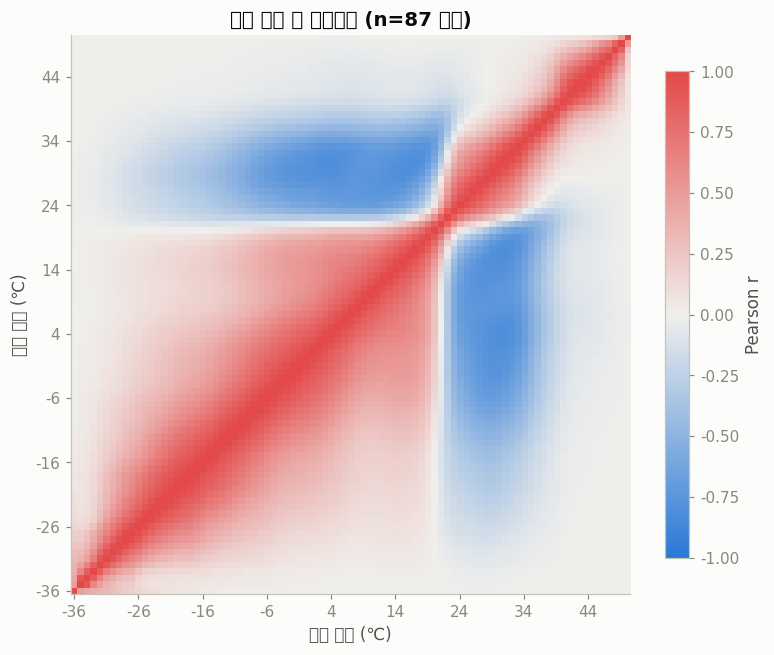

인접 구간 |r| 평균 0.940 (중앙값 0.962)
전체 off-diagonal |r| 최대 0.982
|r| > 0.9 인 구간 쌍: 143


In [9]:
nz = [c for c in GDD if df[c].sum() > 0]
print('노출이 있는 구간: %d개  (%d℃ ~ %d℃), 전부 0인 구간 %d개 제외'
      % (len(nz), temp_of(nz[0]), temp_of(nz[-1]), len(GDD) - len(nz)))

C = df[nz].corr()
tvals = np.array([temp_of(c) for c in nz])

fig, ax = plt.subplots(figsize=(8.2, 7))
ax.grid(False)
im = ax.imshow(C.to_numpy(), cmap=DIVERGING, vmin=-1, vmax=1, origin='lower', interpolation='nearest')
ticks = np.arange(0, len(nz), 10)
ax.set_xticks(ticks); ax.set_xticklabels(tvals[ticks])
ax.set_yticks(ticks); ax.set_yticklabels(tvals[ticks])
ax.set_xlabel('온도 구간 (℃)'); ax.set_ylabel('온도 구간 (℃)')
ax.set_title('노출 구간 간 상관행렬 (n=%d 구간)' % len(nz))
cb = fig.colorbar(im, ax=ax, shrink=0.82)
cb.set_label('Pearson r', color=SECOND); cb.outline.set_edgecolor(AXIS)
save(fig, 'fig07_gdd_corr.png'); plt.show()

M = C.to_numpy()
adj = np.array([abs(M[k, k + 1]) for k in range(len(nz) - 1)])
off = np.abs(M[~np.eye(len(nz), dtype=bool)])
print('인접 구간 |r| 평균 %.3f (중앙값 %.3f)' % (adj.mean(), np.median(adj)))
print('전체 off-diagonal |r| 최대 %.3f' % off.max())
print('|r| > 0.9 인 구간 쌍: %d' % (int((np.abs(M) > 0.9).sum() - len(nz)) // 2))

saved: ../outputs/figures/fig08_corr_decay.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.savefi

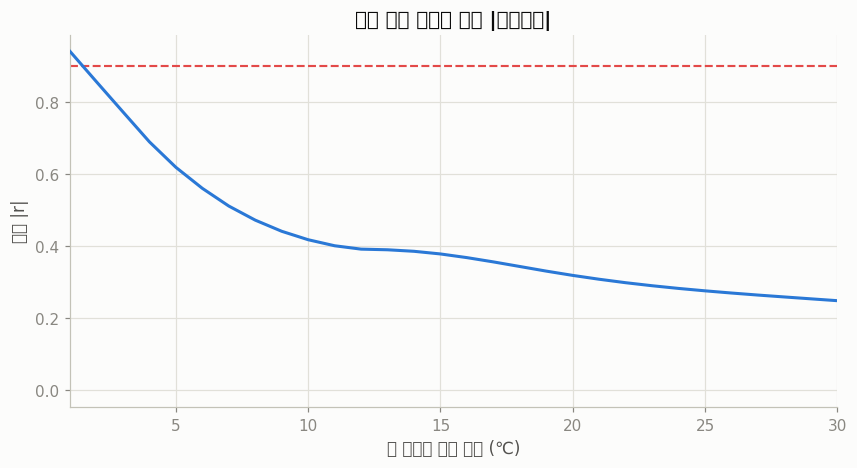

 1℃ 떨어진 구간 쌍의 평균 |r| = 0.940
 2℃ 떨어진 구간 쌍의 평균 |r| = 0.856
 3℃ 떨어진 구간 쌍의 평균 |r| = 0.772
 5℃ 떨어진 구간 쌍의 평균 |r| = 0.618
10℃ 떨어진 구간 쌍의 평균 |r| = 0.418


In [10]:
# 상관이 온도 거리에 따라 얼마나 천천히 줄어드는가
dist, corr = [], []
for a in range(len(nz)):
    for b in range(a + 1, len(nz)):
        dist.append(abs(tvals[a] - tvals[b])); corr.append(abs(M[a, b]))
dd = pd.DataFrame({'d': dist, 'r': corr}).groupby('d')['r'].mean()

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.set_axisbelow(True)
ax.plot(dd.index, dd.values, color=BLUE, zorder=3)
ax.axhline(0.9, color=RED, linestyle='--', linewidth=1.4, zorder=2)
ax.annotate('|r| = 0.9', xy=(dd.index.max() * 0.75, 0.9), xytext=(0, 6),
            textcoords='offset points', color=RED, fontsize=10)
ax.set_xlim(1, 30)
ax.set_title('온도 구간 거리별 평균 |상관계수|')
ax.set_xlabel('두 구간의 온도 차이 (℃)'); ax.set_ylabel('평균 |r|')
save(fig, 'fig08_corr_decay.png'); plt.show()

for k in (1, 2, 3, 5, 10):
    if k in dd.index:
        print('%2d℃ 떨어진 구간 쌍의 평균 |r| = %.3f' % (k, dd.loc[k]))

**해석 — 공선성은 매우 강하다.**

- 인접한 1℃ 구간끼리 **평균 |r| = 0.940** (중앙값 0.962), 최대 off-diagonal |r| = 0.982,
  **|r| > 0.9인 구간 쌍이 143개**다.
- 상관은 온도 거리에 따라 느리게 감소한다: 2℃ 떨어져도 **0.856**, 3℃ **0.772**, 5℃ **0.618**,
  10℃ 떨어져야 비로소 **0.418**이 된다. 히트맵의 굵은 대각 밴드가 그것이다.
- 121개(실질 87개) 컬럼을 그대로 OLS에 넣으면 계수가 불안정해진다. **Ridge/Lasso 같은 정규화**,
  또는 구간 묶기(binning)·다항/스플라인 기저로의 **차원 축소**가 필요하다는 직접적 근거다.
- 좌하단(저온)과 우상단(고온) 블록 사이에는 음의 상관이 보인다: 총 일수가 184로 고정이라
  한쪽이 늘면 다른 쪽이 줄기 때문이다.

## 5. `slope` 결측 점검

`slope` 결측 2,061개가 무작위인지, 특정 지역/시기에 몰려 있는지 확인한다.

In [11]:
na = df[df['slope'].isna()]
print('slope 결측 행: %d (%.2f%%)' % (len(na), 100 * len(na) / len(df)))
print('결측이 있는 카운티 수: %d / %d' % (na['stco'].nunique(), df['stco'].nunique()))

na_cnt = df.groupby('stco')['slope'].apply(lambda s: s.isna().sum())
tot_cnt = df.groupby('stco').size()
full = ((na_cnt == tot_cnt) & (na_cnt > 0)).sum()
part = ((na_cnt > 0) & (na_cnt < tot_cnt)).sum()
print('전 연도 결측 카운티: %d   |   일부 연도만 결측: %d' % (full, part))

print('\n다른 soil 컬럼의 결측 (비교용):')
print(df[SOIL].isna().sum().to_string())

slope 결측 행: 2061 (2.91%)
결측이 있는 카운티 수: 98 / 2644
전 연도 결측 카운티: 88   |   일부 연도만 결측: 10

다른 soil 컬럼의 결측 (비교용):
whc            4
sand           4
silt           4
clay           4
om             4
kwfactor       4
kffactor       4
spH            4
slope       2061
tfactor        4


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.s

saved: ../outputs/figures/fig09_slope_missing.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 45253 (\N{HANGUL SYLLABLE NAEB}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38451/546572780.py:36: UserWarning: Glyph 49399 (\N{HANGUL SYLLABLE SYAS}) missing from font(s) DejaVu Sans.
  fig.savef

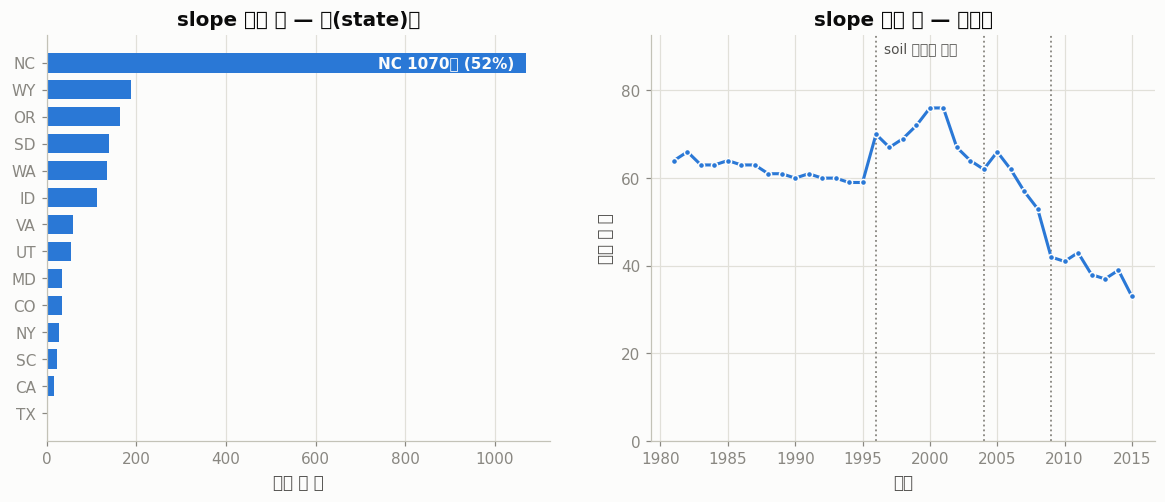

stco
NC    1070
WY     188
OR     163
SD     139
WA     134
ID     113
VA      59
UT      55
CO      35
MD      35
NY      27
SC      23
CA      16
TX       4


In [12]:
FIPS = {6:'CA',8:'CO',16:'ID',24:'MD',36:'NY',37:'NC',41:'OR',45:'SC',
        46:'SD',48:'TX',49:'UT',51:'VA',53:'WA',56:'WY'}
by_state = (na['stco'] // 1000).map(FIPS).value_counts().sort_values()
by_year = na.groupby('year').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]; ax.set_axisbelow(True)
ax.barh(by_state.index, by_state.values, color=BLUE, height=0.72)
ax.set_title('slope 결측 행 — 주(state)별'); ax.set_xlabel('결측 행 수')
ax.grid(axis='y', visible=False)
top = by_state.idxmax()
ax.annotate('%s %d행 (%.0f%%)' % (top, by_state.max(), 100 * by_state.max() / len(na)),
            xy=(by_state.max(), len(by_state) - 1), xytext=(-8, 0),
            textcoords='offset points', ha='right', va='center',
            color=SURFACE, fontsize=10, fontweight='semibold')

ax = axes[1]; ax.set_axisbelow(True)
ax.plot(by_year.index, by_year.values, color=BLUE, marker='o', markersize=4,
        markeredgecolor=SURFACE, markeredgewidth=1.0, zorder=3)
for yr in (1996, 2004, 2009):
    ax.axvline(yr, color=MUTED, linestyle=':', linewidth=1.2, zorder=2)
ax.set_ylim(0, by_year.max() * 1.22)
ax.annotate('soil 스냅샷 경계', xy=(1996, ax.get_ylim()[1]), xytext=(5, -12),
            textcoords='offset points', color=SECOND, fontsize=9)
ax.set_title('slope 결측 행 — 연도별'); ax.set_xlabel('연도'); ax.set_ylabel('결측 행 수')

save(fig, 'fig09_slope_missing.png'); plt.show()
print(by_state.sort_values(ascending=False).to_string())

**해석 — `slope` 결측은 무작위가 아니라 지역적으로 뭉쳐 있다 (MNAR에 가깝다).**

- 결측 2,061행은 **98개 카운티**에서만 나오고, 그중 **88개는 전 연도가 통째로 결측**이다.
  즉 "특정 카운티에 slope 값이 아예 없다"에 가깝고, 랜덤한 셀 누락이 아니다.
- 주별로 보면 **North Carolina가 1,070행(52%)** 으로 압도적이고, 나머지는 WY·OR·SD·WA·ID 등
  **산악·서부 주**에 몰려 있다. 지형이 복잡한 지역에서 slope 산출이 실패한 것으로 보인다.
- 연도별 결측 수는 1996년(soil2001 스냅샷 시작)에 한 번 뛴다 — soil1992는 slope 결측이 139개,
  이후 스냅샷은 154개로 원본 자체가 다르기 때문이다. 이후 완만히 줄어드는 건 해당 카운티들이
  후기 연도에 옥수수 미재배로 빠졌기 때문이다.
- 다른 soil 컬럼은 결측이 4행뿐이므로, `slope`만 특별히 문제다.

**피처 단계 권고**: 카운티 단위로 통째 결측이라 카운티 내 보간(interpolation)은 불가능하다. 선택지는
(a) `slope`를 **제외**, (b) 주(state) 또는 인접 카운티 중앙값으로 대체 + **결측 지시자(indicator) 추가**,
(c) 결측 카운티(3.7%) **제외**. NC가 옥수수 주산지는 아니지만 1,070행은 무시하기 어려우니,
**(b) 중앙값 대체 + indicator**를 기본안으로 권한다.

## 6. 종합 요약

In [13]:
print('=' * 62)
print('EDA 요약')
print('=' * 62)
n_pairs = int((np.abs(M) > 0.9).sum() - len(nz)) // 2
print('패널          : %d행 / %d 카운티 / %d-%d' % (len(df), df.stco.nunique(), df.year.min(), df.year.max()))
print('수확량 추세   : %+.2f bu/ac per year (1981 %.0f -> 2015 %.0f)'
      % (slope_fit, yearly.iloc[0], yearly.iloc[-1]))
print('노출 총합     : 행마다 %.1f일로 고정 -> 분포의 모양만이 정보' % row_sum.mean())
print()
print('[29도 임계 신호]')
print('  above29: 정점 %.1f bu/ac (%.0f일) -> 최저 %.1f bu/ac (%.0f일), 역U자'
      % (cya.max(), cxa[cya.argmax()], cya.min(), cxa[cya.argmin()]))
print('  below29: 정점 %.1f bu/ac (%.0f일) 까지 대체로 단조 증가' % (cyb.max(), cxb[cyb.argmax()]))
print('  연도효과 제거 후에도 꺾임 유지 (정점 %+.1f -> 최저 %+.1f bu/ac 편차)' % (cy.max(), cy.min()))
print('  OLS: below29 %+.3f / above29 %+.3f -> 1일 대체효과 %+.3f bu/ac'
      % (beta[1], beta[2], beta[2] - beta[1]))
print('  주의: below29 vs above29 상관 %.3f (총 184일 고정) -> 계수는 대체효과로만 해석'
      % df.GDD_below29.corr(df.GDD_above29))
print()
print('[다중공선성]')
print('  인접 구간 평균 |r| = %.3f, 최대 |r| = %.3f, |r|>0.9 쌍 = %d' % (adj.mean(), off.max(), n_pairs))
print('  -> Ridge/Lasso 또는 기저함수 축소 필요')
print()
print('[slope 결측]')
print('  %d행 / %d 카운티, 그중 %d개 카운티는 전 연도 결측 (지역 클러스터, MNAR)' % (len(na), na.stco.nunique(), full))
print('  최다: %s %d행' % (by_state.idxmax(), by_state.max()))
print()
print('저장된 그림: %d개 -> %s' % (len(list(FIG.glob('fig*.png'))), FIG.resolve()))

EDA 요약
패널          : 70721행 / 2644 카운티 / 1981-2015
수확량 추세   : +1.77 bu/ac per year (1981 88 -> 2015 151)
노출 총합     : 행마다 184.0일로 고정 -> 분포의 모양만이 정보

[29도 임계 신호]
  above29: 정점 123.1 bu/ac (10일) -> 최저 68.0 bu/ac (74일), 역U자
  below29: 정점 126.1 bu/ac (172일) 까지 대체로 단조 증가
  연도효과 제거 후에도 꺾임 유지 (정점 +11.5 -> 최저 -42.4 bu/ac 편차)
  OLS: below29 +0.537 / above29 -0.128 -> 1일 대체효과 -0.665 bu/ac
  주의: below29 vs above29 상관 -0.901 (총 184일 고정) -> 계수는 대체효과로만 해석

[다중공선성]
  인접 구간 평균 |r| = 0.940, 최대 |r| = 0.982, |r|>0.9 쌍 = 143
  -> Ridge/Lasso 또는 기저함수 축소 필요

[slope 결측]
  2061행 / 98 카운티, 그중 88개 카운티는 전 연도 결측 (지역 클러스터, MNAR)
  최다: NC 1070행

저장된 그림: 31개 -> /Users/leedonggeon/Desktop/Purdue_7/Purdue_code/purdue_git/climate-crop-optimization/outputs/figures
